In [ ]:

# Bicanski 2026 - UCM: universal cognitive maps
# https://doi.org/10.1016/j.cub.2026.08.064
# correspondence: bicanski@cbs.mpg.de


In [ ]:
# Here we add noise during the mapping process

# With noisy x,y during learning we compensate by triangulating each stimulis multiple times. 
# Alternatively we could have noisy grid cells, but we'll take that to be captured,
# to a first approximation, by resultant x_diff and y_diff noise. We assume those perturbations capture 
# the effect of noisy grid cells filtered through interactions with the PIN/VNA

# Noise means adding random offsets to x_diff and y_diff below.


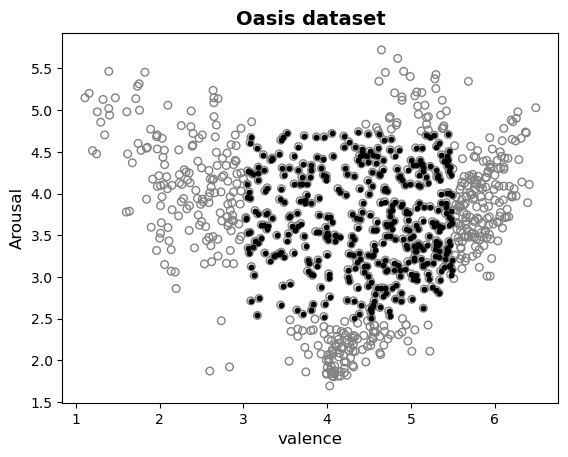

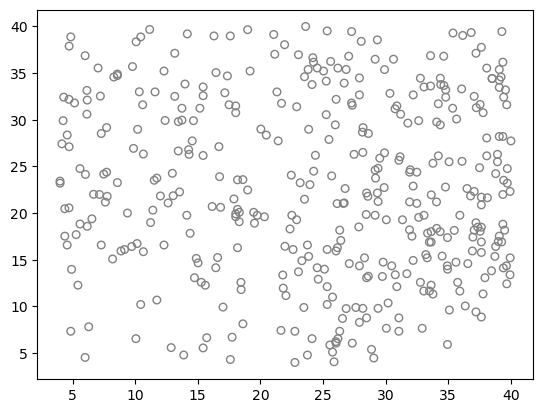

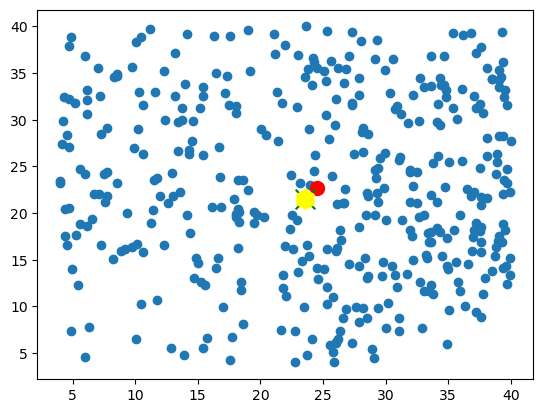

In [1]:
# load first dataset and rescale - same as UCM_oasis_FINAL.ipynb

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from helper_fcts import check_dataset_range
from helper_fcts import load_GCs

from prep_datasets import prep_oasis
from prep_datasets import make_oasis_synthetic
from prep_datasets import get_distances

# grid cells
GCs, res, N_GCs, N_mod, N_per_mod = load_GCs()

data0 = pd.read_csv("datasets/oasis/ExpData/OASIS.csv", sep=None, engine="python")
IDs  = data0.iloc[:, 0].to_numpy()

data, val, aro = prep_oasis(data0,4,res)

eucl_data_dist, v_dist, a_dist = get_distances(data,val,aro)

# check distribution
plt.scatter(val, aro, s=30, facecolors='none', edgecolors=(130/255, 130/255, 130/255))
plt.show()

# now check exact range, though for dataset 1 this is techincally redundant
# in reality startpoint is arbitrary because of periodic torodial grid cell manifold, 
# but our rate maps (as approximation) are not, so start in the middle
# no loss of generality here.
dim1range, dim2range, prop, S1ind, S1coords, N_pts = check_dataset_range(data=data, dim1=val, dim2=aro, mapsize=res)

center = np.mean(data, axis=0)
plt.scatter(data[:,0], data[:,1])
plt.scatter(center[0], center[1], color='red', s=100)
plt.scatter(data[S1ind,0], data[S1ind,1], color='green', s=200, marker='x')
plt.scatter(S1coords[0], S1coords[1], color='yellow', s=200, marker='h')
plt.show()

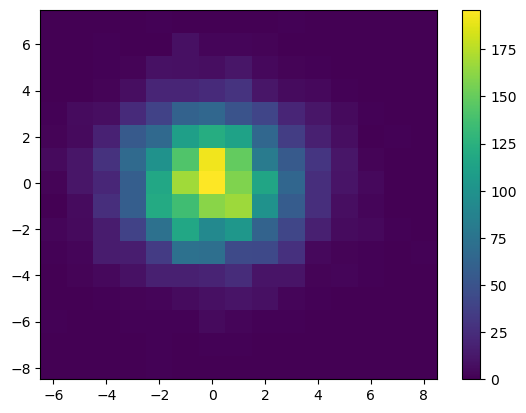

entering second loop


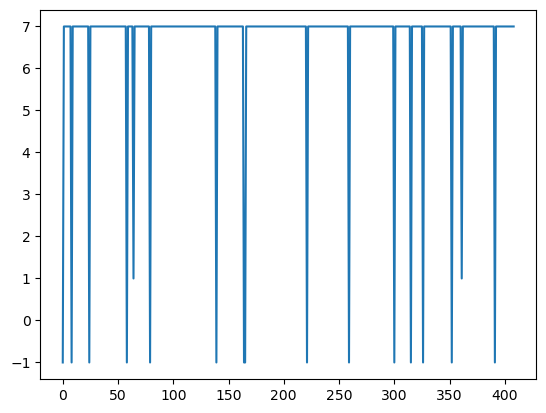

unmapped counter 15


In [ ]:
### Single trial with noise, variable N, where N is the number of anchors considered per mapping event (inference).

# Here we can play with N and see how many stimuli are rejected and remain unplaced.

# Note, we could interpret additional triangulation events as consolidation. If valence and 
# arousal values are memorized individually, nothing stops the system from extracting relations
# later or at least refining the mapping through offline triangulation, i.e., a kind of consolidation.

import numpy as np
import matplotlib.pyplot as plt
from helper_fcts import find_anchors_and_target
from helper_fcts import find_anchors_for_given_target_v2
from helper_fcts import check_output_bounds
from helper_fcts import clip_vect_to_map
from helper_fcts import valid_anchor_indices
from helper_fcts import mean_overlap
from pin import pin

# load dataset and grid cells above

tolerance = 2  # tolerance for vector calc, <5% error for 44 res rate maps, separate from noise

startPV      = GCs[22,22,:]   # no noise here
PVs          = np.zeros([N_pts, N_GCs])
PVs_xy       = np.zeros([N_pts,2]) # model "belief"
PVs_xy_data  = np.zeros([N_pts,2]) # ground truth

PVs_xy[S1ind,0] = 22.  # put at center
PVs_xy[S1ind,1] = 22

PVs[S1ind,:] = startPV

Stims          = np.zeros([N_pts,2])
Stims[S1ind,0] = 10000 + S1ind 
Stims[S1ind,1] += 1

# place second stimulus with minimum distance
S1v        = val[S1ind]
S1a        = aro[S1ind]

x_offset = PVs_xy[S1ind,0]-S1v
y_offset = PVs_xy[S1ind,1]-S1a

PVs_xy_data[S1ind,:] = [val[S1ind]+x_offset,aro[S1ind]+y_offset]

S2ind      = np.random.randint(0, N_pts-1)  # first guess, check below
dist_S1_S2 = eucl_data_dist[S1ind,S2ind]
vect       = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]

while dist_S1_S2 < tolerance:   # check
    S2ind = np.random.randint(0, N_pts-1)
    vect = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]
    dist_S1_S2 = eucl_data_dist[S1ind,S2ind]

PVs_xy_data[S2ind,:] = [val[S2ind]+x_offset,aro[S2ind]+y_offset]

# now we have a candidate data point for S2, 
# still no noise, any discrepancy between intended and actual separation
# we take to just tweak the map scale

wts_mod = np.load("NAVwts/DCad2b_final.npz")
DCxpW   = wts_mod["DCxp_2_tGCs_WTS"]
DCxmW   = wts_mod["DCxm_2_tGCs_WTS"]
DCypW   = wts_mod["DCyp_2_tGCs_WTS"]
DCymW   = wts_mod["DCym_2_tGCs_WTS"]

vect_S1_S2 = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]] # valence and arousal delta
dist_S1_S2 = eucl_data_dist[S1ind,S2ind]

xy_tmp = pin(
    DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
    res=res, vect=vect_S1_S2, xc=22, yc=22, GCs=GCs)

nextPV          = GCs[xy_tmp[1],xy_tmp[0],:]
PVs[S2ind,:]    = nextPV
PVs_xy[S2ind,0] = xy_tmp[0]
PVs_xy[S2ind,1] = xy_tmp[1]
Stims[S2ind,0]  = 10000 + S2ind 
Stims[S2ind,1] += 1

### now let's infer the next grid cell PVs, here we apply noise and average

# noise mechansism:
# since we want to infer the target PV we cannot keep the same target
# coordinates in the N-loop (that would be anticipating the result of the inference). 
# But what we can keep, is the val/aro values of the target
# these are known to the system/subject and can be used to calc vectors relative to anchors. 
# Meaning, we know this from stimulus space, outside of entorhinal cortex. So, we can
# calculate the distance from other anchors to that target, even if we don't 
# know the PV of the target yet. 
# => the anchors vary! The target Valence/arousal does not

###
N = 2 # number of anchor pairs considered. Up if noise grows. 
# Can be changed, e.g., try N=2 vs N=10, then inspect grids below
err_sig = 2.0  # noise in coordinates, higher requires higher N
###
# EXAMPLE: set N to 2, err to 2.0, should could roughly 200 unmapped stimuli
# with low gridness in small scales. The set N to 6, gridness should recover
# don't forget to change N below in the next script for plotting
###

# precalc for speed
Err = np.round(np.clip(np.random.randn(len(Stims[:,0])*2*N,2) * err_sig, -20, 20)).astype(int)
vote_tol = 2

###
configname = f"Noise{int(err_sig*10)}_ftol{tolerance}_N{N}"
###

# check error distribution
x_min, x_max = Err[:,0].min(), Err[:,0].max()
y_min, y_max = Err[:,1].min(), Err[:,1].max()
x_bins = np.arange(x_min-0.5, x_max+1.5)  # ±0.5 for bin edges
y_bins = np.arange(y_min-0.5, y_max+1.5)
plt.hist2d(Err[:,0], Err[:,1], bins=[x_bins, y_bins], cmap='viridis')
plt.colorbar()
plt.show()

err_cnt  = 0
test_cnt = 0

while np.any(Stims[:,0] == 0):

    anchors = valid_anchor_indices(Stims, PVs_xy)
    if anchors.size < 2:
        break

    (A1ind, A2ind, STind, vect_A1_T, dist_A1_T, vect_A2_T, dist_A2_T
        ) = find_anchors_and_target(Stims, eucl_data_dist, tolerance, v_dist, a_dist, PVs_xy)

    if A1ind is None or np.isnan(STind):
        break

    A1xc = int(PVs_xy[A1ind,0])  # coords on grid maps of Anchors - these are internal pointers
    A1yc = int(PVs_xy[A1ind,1])  # we always have anchors.  
    A2xc = int(PVs_xy[A2ind,0])
    A2yc = int(PVs_xy[A2ind,1])

    if not np.isnan(STind):
        
        PVs_xy_tmp1 = np.zeros([N,2])-1
        PVs_xy_tmp2 = np.zeros([N,2])-1
        
        # apply noise to vect
        x1_err = Err[err_cnt,0]; y1_err = Err[err_cnt,1]; err_cnt += 1
        x2_err = Err[err_cnt,0]; y2_err = Err[err_cnt,1]; err_cnt += 1
                
        # clip error such that A1xc, A1yc + vect_A1_T stays in bounds. 
        # the means that we limit noise to the edge of the map. Note,
        # we are not changing vector to target, we just limit overshoot
        # this is a necessity because of static ratemaps. On the torus
        # this would not be necessary
        
        # break PV_xy and PV consistency for noise 
        vect_A1_T_with_noise  = vect_A1_T + np.array([x1_err, y1_err])  # to get PV
        vect_A2_T_with_noise  = vect_A2_T + np.array([x2_err, y2_err])  
        vect_A1_T_noise_safe  = clip_vect_to_map(A1xc, A1yc, vect_A1_T_with_noise, res)
        vect_A2_T_noise_safe  = clip_vect_to_map(A2xc, A2yc, vect_A2_T_with_noise, res)

        xy_tmp1_noise = pin(DCxpW, DCxmW, DCypW, DCymW, res, vect_A1_T_noise_safe, A1xc, A1yc, GCs)
        xy_tmp2_noise = pin(DCxpW, DCxmW, DCypW, DCymW, res, vect_A2_T_noise_safe, A2xc, A2yc, GCs)
        
        # now track result - but in tmp
        PVs_xy_tmp1[0,0:2] = xy_tmp1_noise  # 0:2 because of crazy python slicing, end doesn't count
        PVs_xy_tmp2[0,0:2] = xy_tmp2_noise
        
        Stims[STind,0] = 10000 + STind # to avoid STing = 0 being an index and condition
        Stims[STind,1] = Stims[STind,1] + 1
        
    else: 
        break # no more target to be assigned
    
    
    for i in range(N-1):  # do N total with above, can always find anchors, even if we repeat them                                                                                                                                              

        if i == 0 and np.sum(Stims[:,1]) == 3:
            print("entering second loop")
        
        (A1ind, A2ind, STind, vect_A1_T, dist_A1_T, vect_A2_T, dist_A2_T
            ) = find_anchors_for_given_target_v2(Stims, eucl_data_dist, tolerance, v_dist, a_dist, STind, PVs_xy)
        
        if A1ind is None:
            break

        A1xc = int(PVs_xy[A1ind,0])  # coords on grid maps of Anchors
        A1yc = int(PVs_xy[A1ind,1])  # we always have anchors.  
        A2xc = int(PVs_xy[A2ind,0])  # model internal belief
        A2yc = int(PVs_xy[A2ind,1])
        
        # apply noise to vect
        x1_err = Err[err_cnt,0]; y1_err = Err[err_cnt,1]; err_cnt += 1
        x2_err = Err[err_cnt,0]; y2_err = Err[err_cnt,1]; err_cnt += 1
        
        # we need to break PV_xy and PV consistency for noise    
        vect_A1_T_with_noise  = vect_A1_T + np.array([x1_err, y1_err])  # to get PV
        vect_A2_T_with_noise  = vect_A2_T + np.array([x2_err, y2_err])
        vect_A1_T_noise_safe  = clip_vect_to_map(A1xc, A1yc, vect_A1_T_with_noise, res)
        vect_A2_T_noise_safe  = clip_vect_to_map(A2xc, A2yc, vect_A2_T_with_noise, res)

        ### inference time      
        xy_tmp1_noise = pin(DCxpW, DCxmW, DCypW, DCymW, res, vect_A1_T_noise_safe, A1xc, A1yc, GCs)    
        xy_tmp2_noise = pin(DCxpW, DCxmW, DCypW, DCymW, res, vect_A2_T_noise_safe, A2xc, A2yc, GCs)
        
        PVs_xy_tmp1[i+1,0:2] = xy_tmp1_noise
        PVs_xy_tmp2[i+1,0:2] = xy_tmp2_noise

        Stims[STind,1] = Stims[STind,1] + 1
        #Stims[STind,0] = 10000 + STind 
    
    # mean location
    coords_voted_noise, avgPVs_noise, majority_vote_noise = mean_overlap(PVs_xy_tmp1, PVs_xy_tmp2, vote_tol, GCs)

    # same via average coordinates
    noisePV = GCs[coords_voted_noise[1],coords_voted_noise[0],:]

    # need to reconstruct noisy votedPV via stimulus space groud truth location/coords
    # otherwsie we don't preserve potential for mismatch and noise compensation 
    # can't show its powers

    if np.isnan(STind):
        break 

    ### now track result    
    # we track voted PV which is what the neural response would be
    # we reconstruct later via true coordinates which is akin to experimenter knowldge of map location
        
    ### Iimportant clarification: we use one PV, read via average/voted coordinates/pointers, not an avegered PV. 
    # The system should prioritize a real manifold state, and if there is an attractor, that is
    # what will happen. Averaging vectors could produce off-manifold points, which are not valid
    
    PVs[STind,:]    = noisePV #voted_noisePV
    PVs_xy[STind,0] = coords_voted_noise[0]   # voting on true coordinates is redundant, just for convennience above
    PVs_xy[STind,1] = coords_voted_noise[1]
    Stims[STind,0]  = 10000 + STind          # to avoid STind = 0 being an index and condition    
    Stims[STind,1]  = Stims[STind,1] + 1
    
    PVs_xy_data[STind,:] = [val[STind]+x_offset,aro[STind]+y_offset]
    
    if majority_vote_noise == 0:
        test_cnt += 1
        Stims[STind,1]  = -1  # no confidence if -1, number should trend down with number N of triangulations
        # change N and observe


plt.plot(Stims[:,1])
plt.show()

print('unmapped counter', test_cnt) # show number of unmapped stimuli. Initial anchors used only at start

filename1 = f"datasets/oasis/{configname}_anchored_stimuli.npy"
filename2 = f"datasets/oasis/{configname}_PVs.npy"
filename3 = f"datasets/oasis/{configname}_PVcoordinates.npy"
filename33 = f"datasets/oasis/{configname}_PVcoordinates_data.npy"
filename4 = f"datasets/oasis/{configname}_ErrDist.npy"

np.save(filename1, Stims)
np.save(filename2, PVs)
np.save(filename3, PVs_xy)
np.save(filename33, PVs_xy_data)
np.save(filename4, Err)


configname Noise20_ftol2_N6
[2.9 2.6 2.3 2.  1.7 1.4]


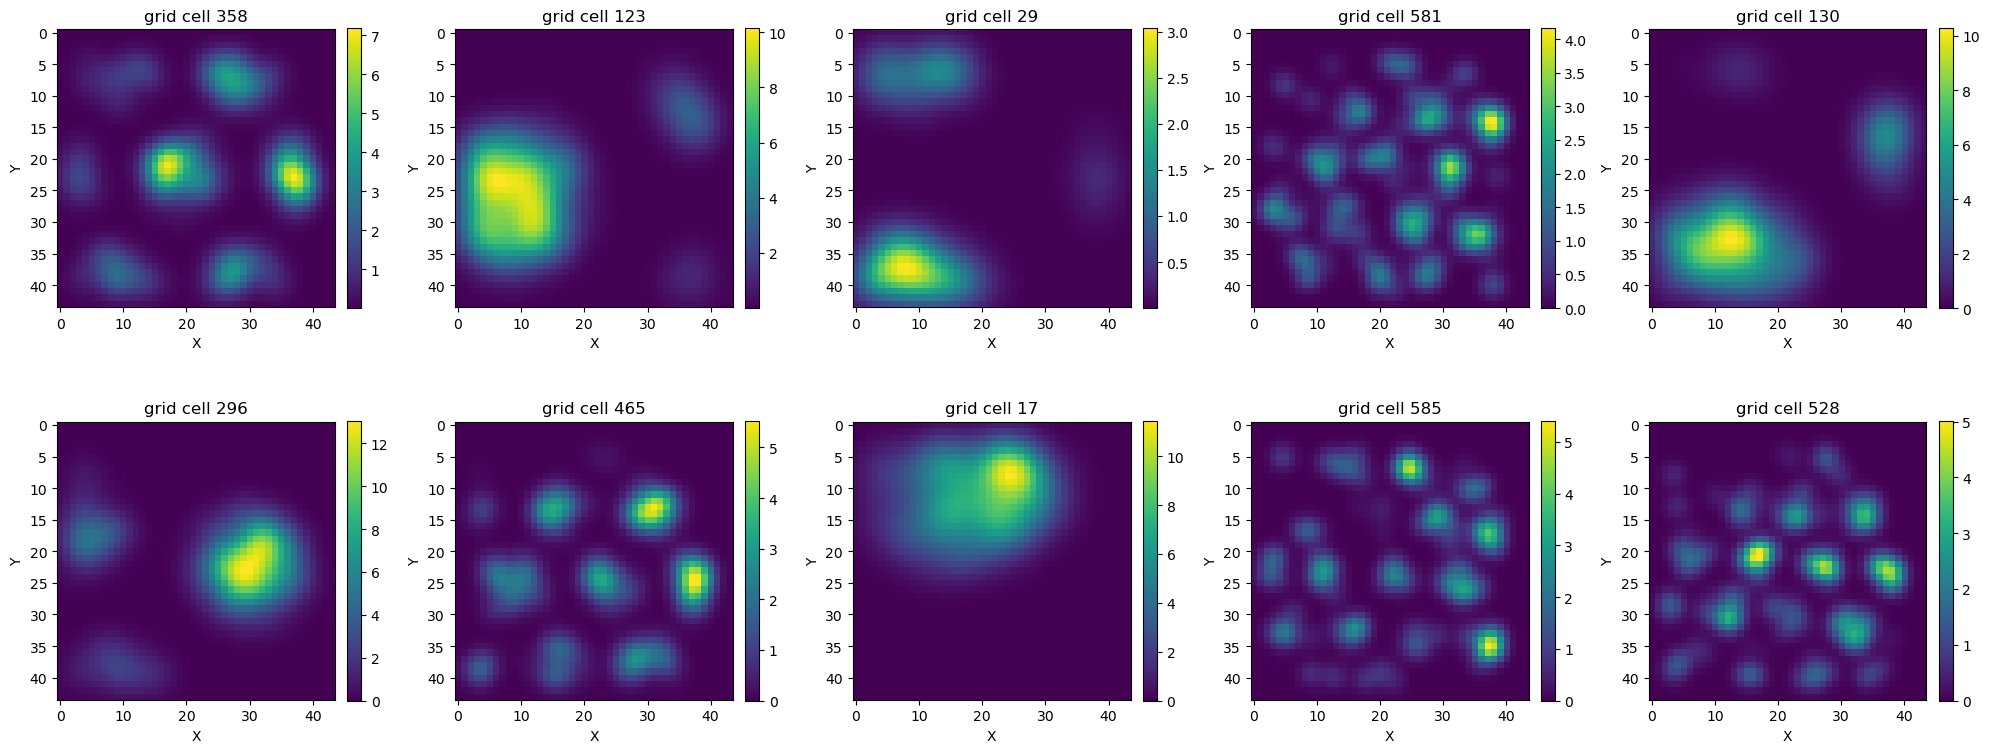

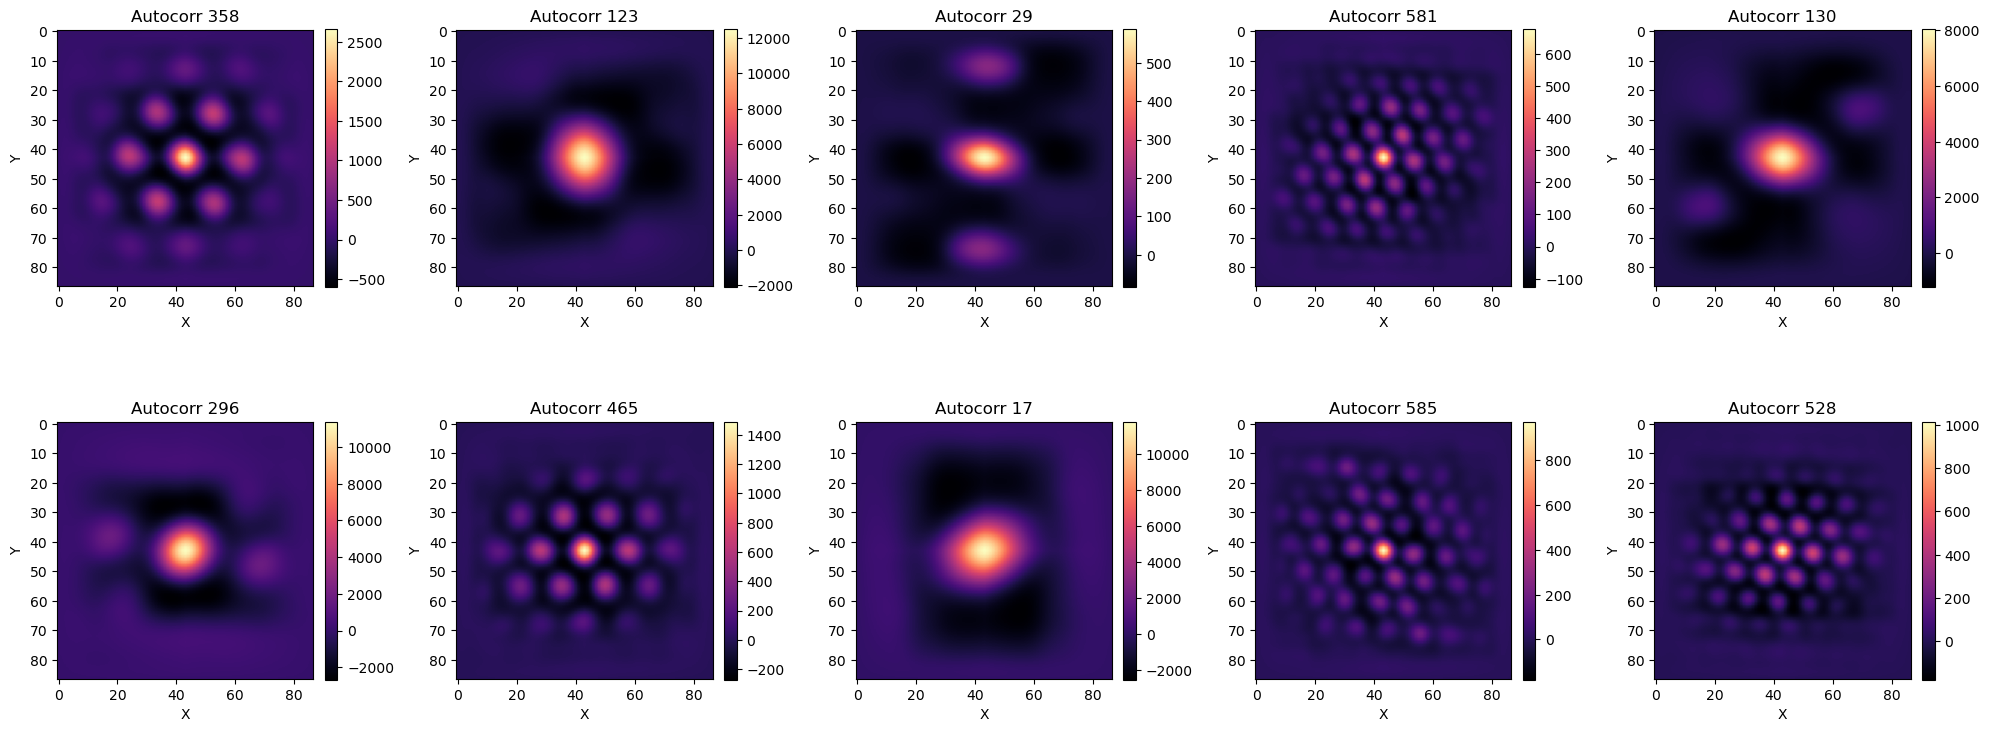

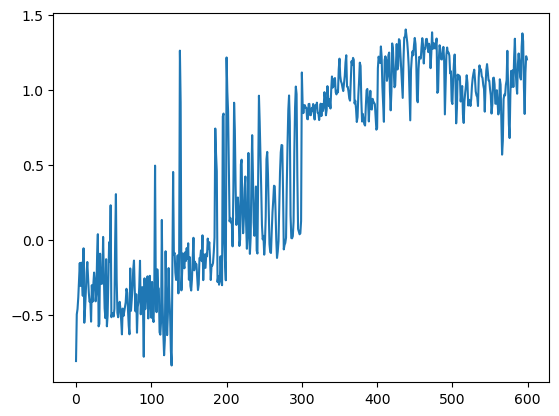

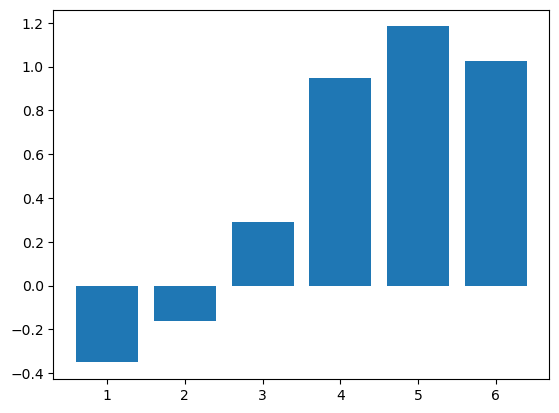

In [5]:
# inspect model output dataset 1 - Noise 1

import numpy as np
from inspect_data_grids import make_data_grids
from inspect_data_grids import plot_data_grids
from inspect_data_grids import plot_correlograms
from inspect_data_grids import plot_gridness
from grid_cells import AutoCorr
from grid_cells import Gridness
from helper_fcts import load_dataset_and_GCs

# Visualize grids

# same rational as in UCM_oasis_FINAL.ipynb

err_sig = 2.0
N = 6
tolerance = 2

###
configname = f"Noise{int(err_sig*10)}_ftol{tolerance}_N{N}"
directory  = 'datasets/oasis/' 
###

print("configname",configname)

Stims, PVs, PVs_xy, PVs_xy_data, GCs, res, N_GCs, N_mod, N_per_mod = load_dataset_and_GCs(configname,directory)

### even number please
N_plots = 10
cells2show = np.random.choice(np.arange(0, N_GCs-1), size=N_plots, replace=False)
###

cleanup = 0 # if we want to set small values to 0

sig = 1.5 # for Gauss HPC Kernel, 0.5 small, 1.5 big
#sigr = np.array([2.8, 2.2, 1.8, 1.7, 1.3, 0.9])*1 
sigr = np.array([2.9, 2.6, 2.3, 2.0, 1.7, 1.4])*1 

dataset_GCs = make_data_grids(N_GCs, res, Stims, PVs_xy_data, PVs, sig, sigr, cleanup)
plot_data_grids(dataset_GCs, N_plots, cells2show)

corr, x, y  = AutoCorr(dataset_GCs, N_GCs, res, h=1)
corr        = corr.data  # because this is a masked array
plot_correlograms(corr, N_plots, cells2show)

G           = Gridness(corr, x, y, N_GCs)
plot_gridness(G)

configname = f"Noise{int(err_sig*10)}_ftol2_N{N}"
savename   = f"datasets/oasis/{configname}_G_Corr_dataGCs.npz"
np.savez(savename, corr=corr, x=x, y=y, G=G, dataset_GCs=dataset_GCs)



  0%|          | 0/2 [00:00<?, ?it/s]

M, N loop 0 1 unplaced 325
M, N loop 0 2 unplaced 331
M, N loop 0 3 unplaced 262
M, N loop 0 4 unplaced 216


 50%|█████     | 1/2 [00:27<00:27, 27.96s/it]

M, N loop 0 5 unplaced 154
M, N loop 1 1 unplaced 307
M, N loop 1 2 unplaced 327
M, N loop 1 3 unplaced 269
M, N loop 1 4 unplaced 211


100%|██████████| 2/2 [01:03<00:00, 31.62s/it]

M, N loop 1 5 unplaced 146


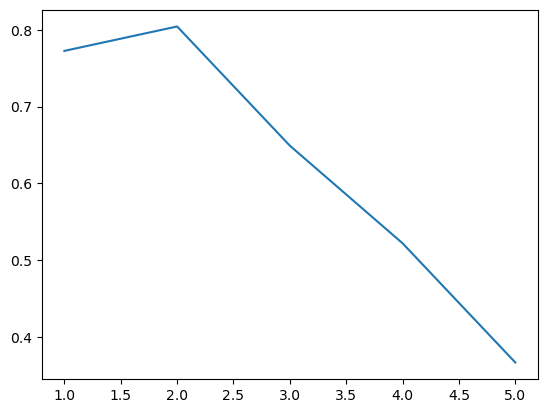

In [5]:
### Same as above but MULTIPLE (M) trials, variable N 

# run NxM iterations for each noise level, set noise level manually and create
# folder "Noise10, ..." if needed.

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from helper_fcts import check_dataset_range
from helper_fcts import load_GCs
from helper_fcts import find_anchors_and_target
from helper_fcts import find_anchors_for_given_target_v2
from helper_fcts import check_output_bounds
from helper_fcts import clip_vect_to_map
from helper_fcts import valid_anchor_indices
from prep_datasets import get_distances
from helper_fcts import mean_overlap
from pin import pin

GCs, res, N_GCs, N_mod, N_per_mod = load_GCs()

data           = np.load("datasets/oasis/OASIS_data_rescaled.npy")
val            = data[:,0]
aro            = data[:,1]

eucl_data_dist, v_dist, a_dist = get_distances(data,val,aro)

tolerance = 2  # tolerance for vector calc, <5% error for 44 res rate maps

vote_tol = 2

N = 5
M = 2

track_vote_failures = np.zeros([N,M])
N_Stims             = np.zeros([len(aro),2,N,M])

# pre calc errors drawn from normal dist
err_sig = 3.0#3.46#1.7 #4 / 2.355 # noise in coordinates
Err = np.round(np.clip(np.random.randn(len(aro)*2*(10*N*M),2) * err_sig, -20, 20)).astype(int)

e_cnt = 0
m_cnt = 0
n_cnt = 0

wts_mod = np.load("NAVwts/DCad2b_final.npz")

DCxpW = wts_mod["DCxp_2_tGCs_WTS"]
DCxmW = wts_mod["DCxm_2_tGCs_WTS"]
DCypW = wts_mod["DCyp_2_tGCs_WTS"]
DCymW = wts_mod["DCym_2_tGCs_WTS"]

for jj in tqdm(range(M)):

    for ii in range(1, N+1):   # avoid ii=0

        dim1range, dim2range, prop, S1ind, S1coords, N_pts = check_dataset_range(data=data, dim1=val, dim2=aro, mapsize=res)

        startPV      = GCs[22,22,:]   # no noise here
        PVs          = np.zeros([N_pts, N_GCs])
        PVs_xy       = np.zeros([N_pts,2])
        PVs_xy_data  = np.zeros([N_pts,2]) # ground truth
        PVs[S1ind,:] = startPV

        PVs_xy[S1ind,0] = 22.  # like in main
        PVs_xy[S1ind,1] = 22

        Stims          = np.zeros([N_pts,2])
        Stims[S1ind,0] = 10000 + S1ind 
        Stims[S1ind,1] += 1

        S1v        = val[S1ind]
        S1a        = aro[S1ind]
        
        x_offset = PVs_xy[S1ind,0]-S1v
        y_offset = PVs_xy[S1ind,1]-S1a
        PVs_xy_data[S1ind,:] = [val[S1ind]+x_offset,aro[S1ind]+y_offset]
        
        S2ind      = np.random.randint(0, N_pts-1)  # first guess, check below
        dist_S1_S2 = eucl_data_dist[S1ind,S2ind]
        vect       = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]

        while dist_S1_S2 < tolerance:   # check
            S2ind = np.random.randint(0, N_pts-1)
            vect = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]
            dist_S1_S2 = eucl_data_dist[S1ind,S2ind]

        PVs_xy_data[S2ind,:] = [val[S2ind]+x_offset,aro[S2ind]+y_offset]

        vect_S1_S2 = [v_dist[S1ind,S2ind], a_dist[S1ind,S2ind]]
        dist_S1_S2 = eucl_data_dist[S1ind,S2ind]

        xy_tmp = pin(
            DCxpW=DCxpW, DCxmW=DCxmW, DCypW=DCypW, DCymW=DCymW,  
            res=res, vect=vect_S1_S2, xc=22, yc=22, GCs=GCs)

        nextPV          = GCs[xy_tmp[1],xy_tmp[0],:]
        PVs[S2ind,:]    = nextPV
        PVs_xy[S2ind,0] = xy_tmp[0]
        PVs_xy[S2ind,1] = xy_tmp[1]
        Stims[S2ind,0]  = 10000 + S2ind 
        Stims[S2ind,1] += 1

        test_cnt = 0
        
        while np.any(Stims[:,0] == 0):

            anchors = valid_anchor_indices(Stims, PVs_xy)
            if anchors.size < 2:
                break

            (A1ind, A2ind, STind, vect_A1_T, dist_A1_T, vect_A2_T, dist_A2_T
                ) = find_anchors_and_target(Stims, eucl_data_dist, tolerance, v_dist, a_dist, PVs_xy)

            if A1ind is None or np.isnan(STind):
                break

            A1xc = int(PVs_xy[A1ind,0])  # coords on grid maps of Anchors
            A1yc = int(PVs_xy[A1ind,1])  # we always have anchors.  
            A2xc = int(PVs_xy[A2ind,0])
            A2yc = int(PVs_xy[A2ind,1])

            if not np.isnan(STind):
                
                PVs_xy_tmp1 = np.zeros([ii,2]) #np.zeros([ii+1,2])
                PVs_xy_tmp2 = np.zeros([ii,2])
                
                # apply noise to vect
                x1_err = Err[e_cnt,0]; y1_err = Err[e_cnt,1]; e_cnt += 1
                x2_err = Err[e_cnt,0]; y2_err = Err[e_cnt,1]; e_cnt += 1
                
                # clip error such that A1xc, A1yc + vect_A1_T stays in bounds. 
                # the means that we limit noise to the edge of the map. Note,
                # we are not changing vector to target, we just limit overshoot
                
                # we need to break PV_xy and PV consistency for noise 
                vect_A1_T_with_noise  = vect_A1_T + np.array([x1_err, y1_err])  # to get PV
                vect_A2_T_with_noise  = vect_A2_T + np.array([x2_err, y2_err])  
                vect_A1_T_noise_safe  = clip_vect_to_map(A1xc, A1yc, vect_A1_T_with_noise, res)
                vect_A2_T_noise_safe  = clip_vect_to_map(A2xc, A2yc, vect_A2_T_with_noise, res)
                
                xy_tmp1_noise = pin(DCxpW, DCxmW, DCypW, DCymW, res, vect_A1_T_noise_safe, A1xc, A1yc, GCs)
                xy_tmp2_noise = pin(DCxpW, DCxmW, DCypW, DCymW, res, vect_A2_T_noise_safe, A2xc, A2yc, GCs)
                
                # now track result - but in tmp
                PVs_xy_tmp1[0,0:2] = xy_tmp1_noise  # 0:2 because of crazy python slicing, end doesn't count
                PVs_xy_tmp2[0,0:2] = xy_tmp2_noise
                
                Stims[STind,0] = 10000 + STind # to avoid STing = 0 being an index and condition
                Stims[STind,1] = Stims[STind,1] + 1
                
            else: 
                break # no more target to be assigned
            
            filled = 1
            
            for i in range(ii-1):  # ii, do N total with above, can always find anchors, even if we repeat them                                                                                                                                              
                
                (A1ind, A2ind, STind, vect_A1_T, dist_A1_T, vect_A2_T, dist_A2_T
                    ) = find_anchors_for_given_target_v2(Stims, eucl_data_dist, tolerance, v_dist, a_dist, STind, PVs_xy)
                
                if A1ind is None:
                    break
                
                A1xc = int(PVs_xy[A1ind,0])  # coords on grid maps of Anchors
                A1yc = int(PVs_xy[A1ind,1])  # we always have anchors.  
                A2xc = int(PVs_xy[A2ind,0])
                A2yc = int(PVs_xy[A2ind,1])
                
                # apply noise to vect
                x1_err = Err[e_cnt,0]; y1_err = Err[e_cnt,1]; e_cnt += 1
                x2_err = Err[e_cnt,0]; y2_err = Err[e_cnt,1]; e_cnt += 1
                
                # we need to break PV_xy and PV consistency for noise 
                vect_A1_T_with_noise  = vect_A1_T + np.array([x1_err, y1_err])  # to get PV
                vect_A2_T_with_noise  = vect_A2_T + np.array([x2_err, y2_err])
                vect_A1_T_noise_safe  = clip_vect_to_map(A1xc, A1yc, vect_A1_T_with_noise, res)
                vect_A2_T_noise_safe  = clip_vect_to_map(A2xc, A2yc, vect_A2_T_with_noise, res)
                
                ### inference time      
                xy_tmp1_noise = pin(DCxpW, DCxmW, DCypW, DCymW, res, vect_A1_T_noise_safe, A1xc, A1yc, GCs)
                xy_tmp2_noise = pin(DCxpW, DCxmW, DCypW, DCymW, res, vect_A2_T_noise_safe, A2xc, A2yc, GCs) 

                PVs_xy_tmp1[i+1,0:2] = xy_tmp1_noise
                PVs_xy_tmp2[i+1,0:2] = xy_tmp2_noise
                
                filled += 1

                Stims[STind,1] = Stims[STind,1] + 1
                #Stims[STind,0] = 10000 + STind 
                
            coords_voted_noise, avgPVs_noise, majority_vote_noise = mean_overlap(PVs_xy_tmp1[:filled], PVs_xy_tmp2[:filled], vote_tol, GCs)

            # use average coordinates as pointers, valid manifold state
            noisePV = GCs[coords_voted_noise[1],coords_voted_noise[0],:]    

            # now track result    
            if np.isnan(STind):
                break 
            
            PVs[STind,:]    = noisePV #voted_noisePV this is fine since STims-1 exclude low confidence votes in the reconstruction
            PVs_xy[STind,0] = coords_voted_noise[0]   # voting on true coordinates is redundant, just for convennience above
            PVs_xy[STind,1] = coords_voted_noise[1]
            Stims[STind,0]  = 10000 + STind          # to avoid STind = 0 being an index and condition    
            Stims[STind,1]  = Stims[STind,1] + 1
            
            PVs_xy_data[STind,:] = [val[STind]+x_offset,aro[STind]+y_offset]
            
            if majority_vote_noise == 0:
                test_cnt += 1
                Stims[STind,1]  = -1  # no confidence in this one, number should trend down with N
        
        print("M, N loop", jj, ii, "unplaced", test_cnt)
        
        # record ---
        track_vote_failures[ii-1, jj] = test_cnt
        N_Stims[:,:,ii-1,jj] = Stims
        
        
        ###
        configname = f"Noise{int(err_sig*10)}_ftol{tolerance}_N{ii}_M{jj}"
        ###
        filename1 = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_anchored_stimuli.npy"
        filename2 = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_PVs.npy"
        filename3 = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_PVcoordinates.npy"
        filename33 = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_PVcoordinates_data.npy"
        filename4 = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_ErrDist.npy"

        np.save(filename1, Stims)
        np.save(filename2, PVs)
        np.save(filename3, PVs_xy)
        np.save(filename33, PVs_xy_data)
        np.save(filename4, Err)

np.savez("datasets/oasis/MappingFailure_vs_N_across_M.npz",track_vote_failures=track_vote_failures,N_Stims=N_Stims)

### prelim check, plot
Npts   = N_Stims.shape[0]
Narr   = range(1, N+1)
m_fail = np.mean(track_vote_failures, axis=1)/Npts
plt.plot(Narr, m_fail)
plt.show()


configname, N, M Noise10_ftol2 1 0
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 2 0
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 3 0
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 4 0
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 5 0
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 1 1
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 2 1
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 3 1
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 4 1
[2.9 2.6 2.3 2.  1.7 1.4]
configname, N, M Noise10_ftol2 5 1
[2.9 2.6 2.3 2.  1.7 1.4]
Saved to datasets/oasis/NM/Noise10/Noise10_ftol2_MNavgs_G.npz


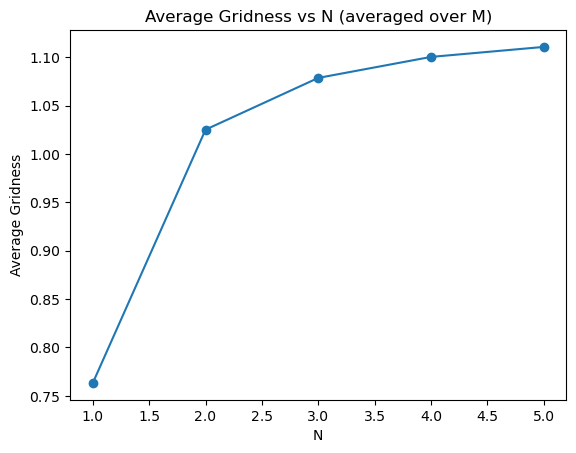

In [8]:
# inspect model output averaged M times for different N

# recommend commenting plotting here, too many plots, we just want to process the data

import numpy as np
from inspect_data_grids import make_data_grids
from inspect_data_grids import plot_data_grids
from inspect_data_grids import plot_correlograms
from inspect_data_grids import plot_gridness
from grid_cells import AutoCorr
from grid_cells import Gridness
from helper_fcts import load_dataset_MN
from helper_fcts import load_GCs
import pickle
import matplotlib.pyplot as plt


# run this separately for each error level
err_sig = 1.0
N = 5
M = 2
tolerance = 2

M_range = range(0, M) #10
N_range = range(1, N+1) #11

GCs, res, N_GCs, N_mod, N_per_mod = load_GCs()

N_plots = 10
cells2show = np.random.choice(np.arange(0, N_GCs-1), size=N_plots, replace=False)
cleanup = 0 # if we want to set small values to 0
sig = 1.5 # for Gauss HPC Kernel, 0.5 small, 1.5 big
sigr = np.array([2.9, 2.6, 2.3, 2.0, 1.7, 1.4])*1 

# accumulate results here 
Gridness_MN    = {}
Corr_MN        = {}
x_MN        = {}
y_MN        = {}
dataset_GCs_MN = {}

for M in M_range:
    for N in N_range:

        ###
        configname = f"Noise{int(err_sig*10)}_ftol{tolerance}"
        directory  = f"datasets/oasis/NM/Noise{int(err_sig*10)}/" 
        print("configname, N, M",configname, N, M)
        ###
        
        Stims, PVs, PVs_xy, PVs_xy_data = load_dataset_MN(configname, directory, M, N)
        
        dataset_GCs = make_data_grids(N_GCs, res, Stims, PVs_xy_data, PVs, sig, sigr, cleanup)
        #plot_data_grids(dataset_GCs, N_plots, cells2show)
        corr, x, y  = AutoCorr(dataset_GCs, N_GCs, res, h=1)
        corr        = corr.data  # because this is a masked array
        #plot_correlograms(corr, N_plots, cells2show)
        G           = Gridness(corr, x, y, N_GCs)
        #plot_gridness(G)
                    
        Gridness_MN[(M, N)] = G
        Corr_MN[(M, N)] = corr
        x_MN[(M, N)] = x
        y_MN[(M, N)] = y
        dataset_GCs_MN[(M, N)] = dataset_GCs

# average across M for each N
avg_Gridness_N = {}
for N in N_range:
    vals = [Gridness_MN[(M, N)] for M in M_range if (M, N) in Gridness_MN]
    if vals:
        mean_over_M = np.mean(vals, axis=0)        # average over M gives shape (600, 1)
        avg_Gridness_N[N] = np.mean(mean_over_M[-100:])  # mean of last module
                
Ns   = sorted(avg_Gridness_N.keys())         
vals = [avg_Gridness_N[N] for N in Ns]        
plt.plot(Ns, vals, marker='o')
plt.xlabel("N")
plt.ylabel("Average Gridness")
plt.title("Average Gridness vs N (averaged over M)")

configname = f"Noise{int(err_sig*10)}_ftol2_MNavgs"
savename   = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_G.npz"

data_to_save = {
    'Gridness_MN':    Gridness_MN,
    'Corr_MN':        Corr_MN,
    'x_MN':           x_MN,
    'y_MN':           y_MN,
    'dataset_GCs_MN': dataset_GCs_MN,
    'avg_Gridness_N': avg_Gridness_N,
}

with open(savename, 'wb') as f:
    pickle.dump(data_to_save, f)
print(f"Saved to {savename}")


Text(0.5, 1.0, 'Average Gridness vs N (averaged over M)')

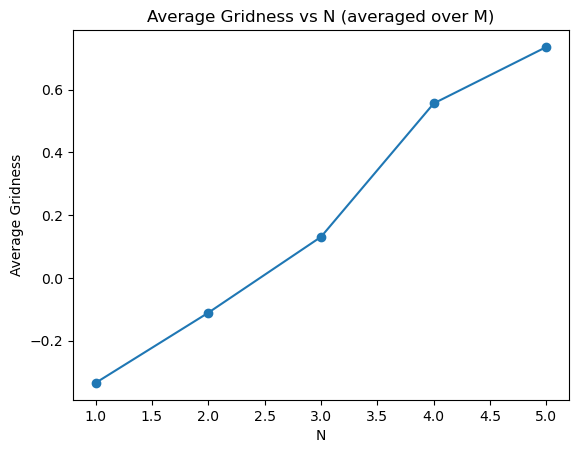

In [11]:
# load processed and plot smallest module gridness as fct of noise level 

err_sig = 3.0

configname = f"Noise{int(err_sig*10)}_ftol2_MNavgs"
savename   = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_G.npz"

with open(savename, 'rb') as f:
    results = pickle.load(f)

Gridness_MN    = results['Gridness_MN']
avg_Gridness_N = results['avg_Gridness_N']

# average across M for each N
avg_Gridness_N = {}
for N in N_range:
    vals = [Gridness_MN[(M, N)] for M in M_range if (M, N) in Gridness_MN]
    if vals:
        mean_over_M = np.mean(vals, axis=0)        # average over M gives shape (600, 1)
        avg_Gridness_N[N] = np.mean(mean_over_M[-100:])  # mean of last module
        
Ns   = sorted(avg_Gridness_N.keys())     
vals = [avg_Gridness_N[N] for N in Ns]      

plt.plot(Ns, vals, marker='o')
plt.xlabel("N")
plt.ylabel("Average Gridness")
plt.title("Average Gridness vs N (averaged over M)")

configname, N, M Noise10_ftol2_N1_M0 1 0
configname, N, M Noise10_ftol2_N2_M0 2 0
configname, N, M Noise10_ftol2_N3_M0 3 0
configname, N, M Noise10_ftol2_N4_M0 4 0
configname, N, M Noise10_ftol2_N5_M0 5 0
configname, N, M Noise10_ftol2_N1_M1 1 1
configname, N, M Noise10_ftol2_N2_M1 2 1
configname, N, M Noise10_ftol2_N3_M1 3 1
configname, N, M Noise10_ftol2_N4_M1 4 1
configname, N, M Noise10_ftol2_N5_M1 5 1
configname, N, M Noise20_ftol2_N1_M0 1 0
configname, N, M Noise20_ftol2_N2_M0 2 0
configname, N, M Noise20_ftol2_N3_M0 3 0
configname, N, M Noise20_ftol2_N4_M0 4 0
configname, N, M Noise20_ftol2_N5_M0 5 0
configname, N, M Noise20_ftol2_N1_M1 1 1
configname, N, M Noise20_ftol2_N2_M1 2 1
configname, N, M Noise20_ftol2_N3_M1 3 1
configname, N, M Noise20_ftol2_N4_M1 4 1
configname, N, M Noise20_ftol2_N5_M1 5 1
configname, N, M Noise30_ftol2_N1_M0 1 0
configname, N, M Noise30_ftol2_N2_M0 2 0
configname, N, M Noise30_ftol2_N3_M0 3 0
configname, N, M Noise30_ftol2_N4_M0 4 0
configname, N, M

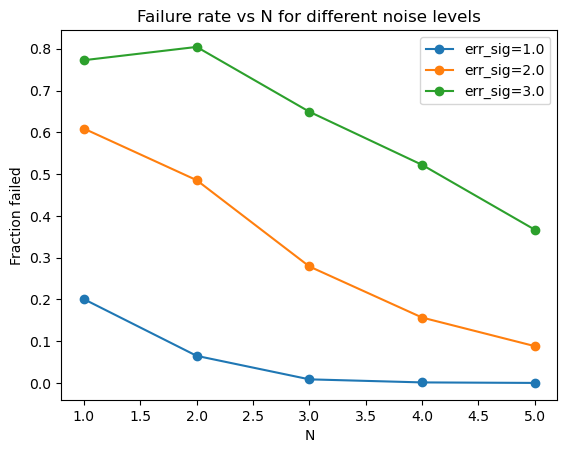

In [19]:
# load processed and load failure rate as function of noise level

# here for multiple noise levels

import numpy as np
import matplotlib.pyplot as plt

N = 5
M = 2

tolerance = 2

M_range = range(0, M) #10
N_range = range(1, N+1) #11

err_sigs  = [1.0, 2.0, 3.0]

n_fail = np.zeros((len(M_range), len(N_range),len(err_sigs)))

for i in range(3):

    err_sig = err_sigs[i]   

    for m in M_range:
        for n in N_range:
            ###
            configname = f"Noise{int(err_sig*10)}_ftol{tolerance}_N{n}_M{m}"
            directory  = f"datasets/oasis/NM/Noise{int(err_sig*10)}/" 
            print("configname, N, M",configname, n, m)
            ###
        
            filename1 = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_anchored_stimuli.npy"
            Stims = np.load(filename1)
            S     = Stims[:,1]
            n_fail[m,n-1,i] = np.sum(S==-1) # failed to place these

n_fail = n_fail/len(S) # proportion

# average over M and plot three lines of n_fail vs N for the three err_sigs here

# average over M (axis 0)
n_fail_avg = np.mean(n_fail, axis=0) 

for i, err_sig in enumerate(err_sigs):
    plt.plot(N_range, n_fail_avg[:, i], marker='o', label=f"err_sig={err_sig}")

plt.xlabel("N")
plt.ylabel("Fraction failed")
plt.legend()
plt.title("Failure rate vs N for different noise levels")
plt.show()

savename = f"datasets/oasis/MappingFailure_vs_N_across_M_3NoiseLevels.npz"

np.savez(savename,n_fail=n_fail,n_fail_avg=n_fail_avg,S=S)



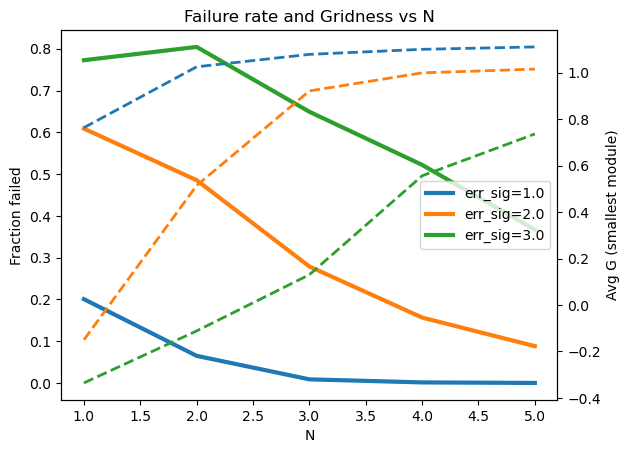

In [20]:
# plot gridness and prob of failure to place as fct of noise level
# this is the last panel of figure 3

import numpy as np
import matplotlib.pyplot as plt
import pickle

data       = np.load('datasets/oasis/MappingFailure_vs_N_across_M_3NoiseLevels.npz')
n_fail     = data['n_fail']
n_fail_avg = data['n_fail_avg']
S          = data['S']

err_sigs  = [1.0, 2.0, 3.0]
N = 5
M = 2
tolerance = 2

M_range = range(0, M) #10
N_range = range(1, N+1) #11

colors = plt.cm.tab10.colors 

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()  # second y-axis for gridness

for i, err_sig in enumerate(err_sigs):
    
    color = colors[i]
    
    ax1.plot(N_range, n_fail_avg[:, i], marker='', color=color, label=f"err_sig={err_sig}",linewidth=3)
    
    configname = f"Noise{int(err_sig*10)}_ftol2_MNavgs"
    loadname   = f"datasets/oasis/NM/Noise{int(err_sig*10)}/{configname}_G.npz"
    
    with open(loadname, 'rb') as f:
        results = pickle.load(f)
    Gridness_MN = results['Gridness_MN']
    
    avg_Gridness_N = {}
    for N in N_range:
        vals = [Gridness_MN[(M, N)] for M in M_range if (M, N) in Gridness_MN]
        if vals:
            mean_over_M = np.mean(vals, axis=0)
            avg_Gridness_N[N] = np.mean(mean_over_M[-100:])
    
    Ns   = sorted(avg_Gridness_N.keys())
    gvals = [avg_Gridness_N[N] for N in Ns]
    ax2.plot(Ns, gvals, marker='', linestyle='--', color=color,linewidth=2)

ax1.set_xlabel("N")
ax1.set_ylabel("Fraction failed")
ax2.set_ylabel("Avg G (smallest module)")
ax1.legend()
ax1.legend(loc='center right')
plt.title("Failure rate and Gridness vs N")
plt.show()